# NGC 5010: Fitting the Phoenix Model to Real GECKOS/MUSE Maps

Same workflow as `optimization_pipeline2_NGC3630.ipynb`, applied to **NGC 5010**. The observed maps are the nGIST-reduced GECKOS/MUSE kinematics loaded by `geckos_data.load_geckos_maps`; the fit is kinematic (`v_rot`, `sigma`), and it is run **once at a constant smoothing bandwidth** — no coarse-to-fine annealing (see "Why no annealing" below).

## How NGC 5010 differs from NGC 3630

The two galaxies need different settings, and the data itself says why:

| measured on the loaded maps | NGC 5010 | NGC 3630 |
|---|---|---|
| x-coverage | **symmetric**, -6.8 to +6.8 kpc | -1.4 to +5.8 kpc (63% off-centre) |
| central vs outer dispersion (r<1 kpc / r>2.5 kpc) | **1.23** | 1.74 |
| peak sigma | 112 km/s | 167 km/s |
| rotation | -180 to +183 km/s | -173 to +146 km/s |

Consequently:

- **`center_percentile=None`.** The pointing is well centred, so the global flux-weighted centroid is the right centre. (NGC 3630 needed centring on the nucleus because its offset pointing dragged the centroid toward the covered side.)
- **`spheroid_corotation=1.0`.** With only a 1.23 central dispersion enhancement this galaxy is rotation-dominated, not hosting a strongly dispersion-supported core, so the spheroid is modelled as co-rotating with the disk. (NGC 3630, with a 1.74 ratio and a sharp sigma peak, used 0.5 — a pressure-supported bulge.)
- **`L0` bounded (2, 8)** rather than (2, 5), and a larger field: `extent = 7 x 4` kpc.

Everything else follows `fit_geckos.py` and the NGC 3630 notebook: `loss_weights = (0, 2, 3, 0)` — the MUSE FLUX is *light* not mass (its normalization is fiducial and its sharp nucleus is not reproducible by a 3-component model), and the Poisson self-consistency term is off because a real galaxy cannot be pre-made self-consistent the way the mock could. The disk dispersion is capped so any central sigma excess must come from the bulge, and a mild Tikhonov prior anchors the parameters the kinematics leave degenerate.

**There is no ground truth**, so nothing here is scoreable: the fitted values are an answer, not a score. Without a second optimization path to compare against, the only remaining diagnostics are the zero-gradient probe (Section 2), bound proximity, and how far each parameter moved from its initial guess.


In [1]:
import os
import sys
import copy
import math
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sys.path.insert(0, os.path.abspath('.'))
from geckos_data import load_geckos_maps

from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper
from phoenix.optimization.pipeline import fit, make_loss_fn, params_to_log, DEFAULT_PARAM_BOUNDS
from phoenix.optimization.observables import render_maps_batched

/home/annalena/phoenix/phoenix/distribution_functions/disk.py:14: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one of the two lines below.
from typeguard import typechecked as typechecker
from beartype import beartype as typechecker

@jaxtyped(typechecker=typechecker)
def foo(...):
```
and the old double-decorator syntax
```
@jaxtyped
@typechecker
def foo(...):
```
should no longer be used. (It will continue to work as it did before, but the new approach will produce more readable error messages.)
In particular note that `typechecker` must be passed via keyword argument; the following is not valid:
```
@jaxtyped(typechecker)
def foo(...):
```

  @jaxtyped
/home/annalena/phoenix/phoenix/distribution_functions/disk.py:21: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one o

## 1. The Observed Galaxy

Distance and stellar mass from the GECKOS master catalogue, as in `fit_geckos.py`:
`kpc/arcsec = D[Mpc]*1e3/206265`, `Mstar = 10**lmstar`.

In [2]:
NAME = 'NGC5010'
STEM = 'NGC5010_iDR2.0_1_SN100_5_MW_4800-8900'
DATADIR = os.path.join('data', '7_NGC5010', 'maps', STEM)

D_MPC = 42.2               # GECKOS master catalogue
LMSTAR = 10.6833
KPC_PER_ARCSEC = D_MPC * 1e3 / 206265.0
MSTAR = 10.0 ** LMSTAR

EXTENT_X, EXTENT_Z = 7.0, 4.0
GRID_SIZE = 40
CENTER_PERCENTILE = None    # well-centred pointing -> global flux centroid is correct
SPHEROID_COROTATION = 1.0   # rotation-dominated, no strongly hot core

obs_maps, info = load_geckos_maps(
    os.path.join(DATADIR, f'{STEM}_kin_maps.fits'),
    os.path.join(DATADIR, f'{STEM}_spatial_binning_maps.fits'),
    kpc_per_arcsec=KPC_PER_ARCSEC, extent_x=EXTENT_X, extent_z=EXTENT_Z,
    grid_size=GRID_SIZE, Mstar_fiducial=MSTAR, center_percentile=CENTER_PERCENTILE,
)

data_mask = np.array(obs_maps['mass']) > 0
vmax_mass = float(np.nanmax(np.array(obs_maps['mass'])))

print(f"{NAME}:  D = {D_MPC} Mpc -> {KPC_PER_ARCSEC:.4f} kpc/arcsec,  logM* = {LMSTAR}")
print(f"  PA = {info['position_angle_deg']:.1f} deg,  v_sys = {info['v_systemic_kms']:.1f} km/s")
print(f"  filled cells: {int(data_mask.sum())}/{GRID_SIZE**2} ({info['filled_fraction']*100:.0f}%)")
v, s = np.array(obs_maps['v_rot']), np.array(obs_maps['sigma'])
print(f"  v_rot in [{v[data_mask].min():.0f}, {v[data_mask].max():.0f}] km/s")
print(f"  sigma in [{s[data_mask].min():.0f}, {s[data_mask].max():.0f}] km/s")

# Quantify the two properties that set the modelling choices above.
_xc = 0.5 * (np.linspace(-EXTENT_X, EXTENT_X, GRID_SIZE + 1)[:-1]
             + np.linspace(-EXTENT_X, EXTENT_X, GRID_SIZE + 1)[1:])
_zc = 0.5 * (np.linspace(-EXTENT_Z, EXTENT_Z, GRID_SIZE + 1)[:-1]
             + np.linspace(-EXTENT_Z, EXTENT_Z, GRID_SIZE + 1)[1:])
_X, _Z = np.meshgrid(_xc, _zc)
_r = np.hypot(_X, _Z)
core, outer = (_r < 1.0) & data_mask, (_r > 2.5) & data_mask
print(f"  x-coverage [{_X[data_mask].min():+.1f}, {_X[data_mask].max():+.1f}] kpc "
      f"-> {abs(_X[data_mask].min() + _X[data_mask].max()) / np.ptp(_X[data_mask]) * 100:.0f}% off-centre")
print(f"  sigma core(r<1) = {s[core].mean():.0f} km/s,  outer(r>2.5) = {s[outer].mean():.0f} km/s"
      f"  -> ratio {s[core].mean() / s[outer].mean():.2f}")

NGC5010:  D = 42.2 Mpc -> 0.2046 kpc/arcsec,  logM* = 10.6833
  PA = 30.9 deg,  v_sys = 1.2 km/s
  filled cells: 558/1600 (35%)
  v_rot in [-180, 183] km/s
  sigma in [40, 112] km/s
  x-coverage [-6.8, +6.8] kpc -> 0% off-centre
  sigma core(r<1) = 78 km/s,  outer(r>2.5) = 64 km/s  -> ratio 1.23


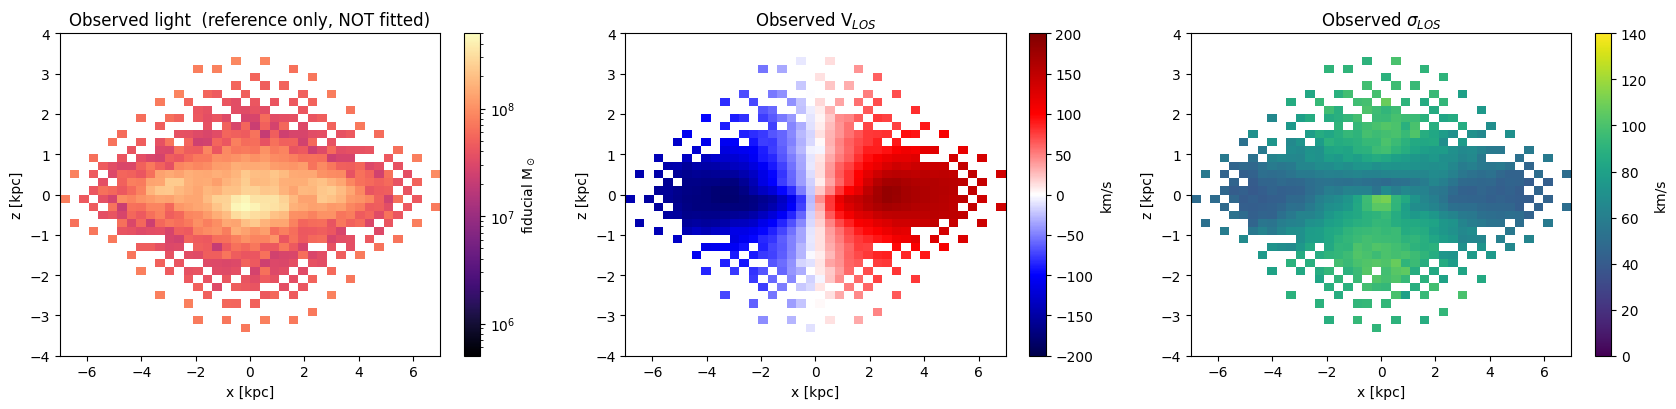

In [3]:
EXTENT = [-EXTENT_X, EXTENT_X, -EXTENT_Z, EXTENT_Z]
SIGMA_VMAX = 140.0     # NGC 5010 peaks near 112 km/s

def masked(a):
    return np.where(data_mask, np.array(a), np.nan)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
im = axes[0].imshow(masked(obs_maps['mass']), origin='lower', extent=EXTENT, cmap='magma',
                    norm=LogNorm(vmin=vmax_mass / 1e3, vmax=vmax_mass), aspect='auto')
axes[0].set_title('Observed light  (reference only, NOT fitted)')
fig.colorbar(im, ax=axes[0], label='fiducial M$_\\odot$')
im = axes[1].imshow(masked(obs_maps['v_rot']), origin='lower', extent=EXTENT,
                    cmap='seismic', vmin=-200, vmax=200, aspect='auto')
axes[1].set_title('Observed V$_{LOS}$'); fig.colorbar(im, ax=axes[1], label='km/s')
im = axes[2].imshow(masked(obs_maps['sigma']), origin='lower', extent=EXTENT,
                    cmap='viridis', vmin=0, vmax=SIGMA_VMAX, aspect='auto')
axes[2].set_title('Observed $\\sigma_{LOS}$'); fig.colorbar(im, ax=axes[2], label='km/s')
for ax in axes:
    ax.set_xlabel('x [kpc]'); ax.set_ylabel('z [kpc]')
plt.tight_layout(); plt.show()

## 2. Fit Configuration

As in the NGC 3630 notebook, `OBS_BANDWIDTH` is a **modelling choice**, not a measured PSF: the data's effective resolution comes from seeing (~0.8" ~ 0.16 kpc at 42 Mpc), the Voronoi binning, and the 0.35 kpc grid cell. 0.4 kpc is the resolution the observation is treated as having, and the fit runs at that bandwidth throughout: `anneal_bandwidth=(0.4, 0.4)` (constant).


### Why no annealing

Bandwidth annealing exists to cure the vanishing gradient of the masked log-*mass* term when the model and data maps do not overlap. Here `w_mass = 0`, so that failure mode never arises, while the wide-bandwidth stages blur away the rotation dipole and the central sigma structure the loss actually depends on. On NGC 3630 the constant-bandwidth run already won on both counts (final loss 0.0632 vs 0.0779; `v_rot` residual RMS 21.2 vs 24.4 km/s).

There is also a problem intrinsic to blurring *real* data with partial coverage. Evaluated at fixed parameters, the annealed loss varies ~5x with bandwidth (0.194 at h=4, peaking 0.277 at h=2, down to 0.056 at h=0.4) for two reasons: the observation is not a Gaussian KDE at `obs_bandwidth` (it is flux summed into cells, so blurring it does not reproduce what the model's KDE at h produces), and the footprint has a hard edge which blurring smears into a soft one that the model — which extends beyond the observed region — cannot match. So the intermediate objectives an annealed run optimizes are distorted, and it buys nothing on kinematic maps.

The constant-bandwidth run compares like with like at every step and is unaffected by any of this.


In [4]:
N_PARTICLES = 20_000       # fit_geckos.py uses 35_000 for production; reduced here for runtime
N_PARTICLES_RENDER = 100_000
N_STEPS = 600
SEED = 0
LEARNING_RATE = 0.05
OBS_BANDWIDTH = 0.4
LOSS_WEIGHTS = (0.0, 2.0, 3.0, 0.0)     # (mass, v_rot, sigma, poisson): kinematic-only
REG_WEIGHT = 0.05

init_pot = {'M_halo': 8e11, 'a_halo': 15.0, 'M_disk': 4e10, 'a_disk': 2.0,
            'b_disk': 0.2, 'M_bulge': 5e9, 'a_bulge': 0.5}
init_disk = {'R0': 4.0, 'Rd': 1.5, 'Sigma0': 1000.0, 'RsigR': 5.0, 'RsigZ': 5.0,
             'sigmaR0_R0': 60.0, 'sigmaz0_R0': 40.0, 'L0': 3.0, 'Rinit_for_Rc': 4.0}
init_bulge = {'N0_spheroid': 5e9, 'J0_spheroid': 60.0, 'Gamma_spheroid': 1.5,
              'Beta_spheroid': 4.5, 'eta_spheroid': 1.0}

param_bounds = copy.deepcopy(DEFAULT_PARAM_BOUNDS)
param_bounds['disk']['L0'] = (2.0, 8.0)             # NGC 5010: (2, 8), cf. (2, 5) for NGC 3630
param_bounds['disk']['sigmaR0_R0'] = (5.0, 120.0)   # cap the disk so any central sigma
param_bounds['disk']['sigmaz0_R0'] = (5.0, 90.0)    #   excess must come from the bulge

FIT_KW = dict(
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
    loss_weights=LOSS_WEIGHTS, poisson_kwargs={},
    learning_rate=LEARNING_RATE, n_steps=N_STEPS,
    spheroid_corotation=SPHEROID_COROTATION, param_bounds=param_bounds,
    obs_bandwidth=OBS_BANDWIDTH, reg_weight=REG_WEIGHT,
)

mapper = PhoenixMapper()

Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz
Model loaded and ready for inference!


### Which parameters can this dataset constrain?

Measured, not assumed. `Sigma0` and `N0_spheroid` are degenerate for *any* dataset (the tracer weights are renormalized, so an overall DF amplitude cancels exactly); others may be degenerate for this particular loss. Anything with a numerically zero gradient can only drift, so it is frozen.

In [5]:
probe_loss = make_loss_fn(
    mapper, obs_maps,
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
    loss_weights=LOSS_WEIGHTS, poisson_kwargs={},
    spheroid_corotation=SPHEROID_COROTATION, obs_bandwidth=OBS_BANDWIDTH,
)
(_l, _a), grads = jax.value_and_grad(probe_loss, has_aux=True)(
    params_to_log(init_pot, init_disk, init_bulge), OBS_BANDWIDTH)

print("|d loss / d log(param)| at the initial guess:")
flat = [(abs(float(g)), grp, k) for grp in ('pot', 'disk', 'bulge')
        for k, g in grads[grp].items()]
for mag, grp, k in sorted(flat, reverse=True):
    tag = '   <-- numerically zero: unconstrained' if mag < 1e-6 else ''
    print(f"  {grp:6s} {k:16s} {mag:.3e}{tag}")

FROZEN = tuple(k for mag, _, k in flat if mag < 1e-6)
print(f"\nfreezing: {FROZEN}")

|d loss / d log(param)| at the initial guess:
  pot    a_halo           4.035e-01
  pot    a_disk           1.608e-01
  pot    M_disk           1.526e-01
  pot    M_bulge          9.986e-02
  pot    M_halo           7.765e-02
  disk   Rd               5.872e-02
  disk   RsigR            4.504e-02
  pot    a_bulge          3.805e-02
  disk   RsigZ            3.432e-02
  pot    b_disk           2.509e-02
  disk   sigmaz0_R0       1.485e-02
  disk   sigmaR0_R0       1.252e-02
  disk   R0               1.870e-03
  bulge  Beta_spheroid    2.090e-04
  bulge  Gamma_spheroid   8.873e-05
  bulge  J0_spheroid      6.933e-05
  disk   L0               6.926e-05
  bulge  eta_spheroid     1.729e-05
  disk   Sigma0           1.819e-09   <-- numerically zero: unconstrained
  disk   Rinit_for_Rc     7.140e-18   <-- numerically zero: unconstrained
  bulge  N0_spheroid      0.000e+00   <-- numerically zero: unconstrained

freezing: ('Rinit_for_Rc', 'Sigma0', 'N0_spheroid')


## 3. Fit — Constant Bandwidth

In [6]:
result = fit(mapper, obs_maps, init_pot, init_disk, init_bulge,
             anneal_bandwidth=(OBS_BANDWIDTH, OBS_BANDWIDTH),
             frozen_params=FROZEN, **FIT_KW)
h = result['history']
print(f"loss {h['loss'][0]:8.4f} -> {h['loss'][-1]:8.4f}"
      + ('   [NaN!]' if not np.isfinite(h['loss'][-1]) else ''))
print(f"     v_rot {h['vrot_loss'][-1]:.4f}   sigma {h['sigma_loss'][-1]:.4f}"
      f"   reg {h['reg'][-1]:.4f}")


loss   0.1696 ->   0.0541
     v_rot 0.0071   sigma 0.0119   reg 0.0042


In [7]:
# Persist the expensive result so a later cell (or crash) never costs another refit.
import json as _json
with open(f'{NAME}_fit_results_naive.json', 'w') as _fh:
    _json.dump({
        'galaxy': NAME,
        'config': {'D_MPC': D_MPC, 'LMSTAR': LMSTAR, 'GRID_SIZE': GRID_SIZE,
                   'EXTENT_X': EXTENT_X, 'EXTENT_Z': EXTENT_Z,
                   'N_PARTICLES': N_PARTICLES, 'N_STEPS': N_STEPS,
                   'OBS_BANDWIDTH': OBS_BANDWIDTH, 'LOSS_WEIGHTS': list(LOSS_WEIGHTS),
                   'REG_WEIGHT': REG_WEIGHT, 'FROZEN': list(FROZEN),
                   'SPHEROID_COROTATION': SPHEROID_COROTATION,
                   'CENTER_PERCENTILE': CENTER_PERCENTILE},
        'naive': {'pot_params': {k: float(v) for k, v in result['pot_params'].items()},
                  'disk_df_params': {k: float(v) for k, v in result['disk_df_params'].items()},
                  'bulge_df_params': {k: float(v) for k, v in result['bulge_df_params'].items()},
                  'final_loss': float(h['loss'][-1])},
    }, _fh, indent=2)
print(f'wrote {NAME}_fit_results_naive.json')


wrote NGC5010_fit_results_naive.json


## 4. Convergence

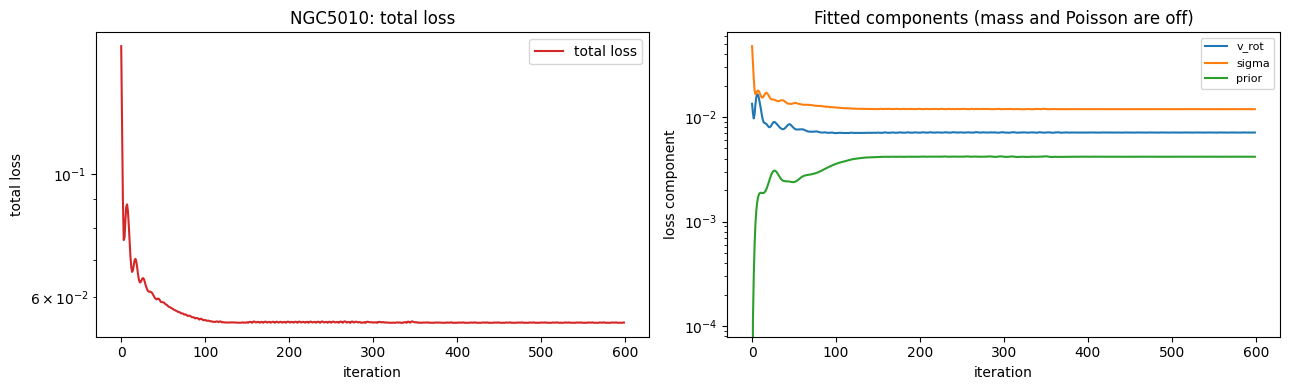

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(h['loss'], color='tab:red', label='total loss')
axes[0].set_yscale('log'); axes[0].set_xlabel('iteration'); axes[0].set_ylabel('total loss')
axes[0].set_title(f'{NAME}: total loss'); axes[0].legend()

for key, lab in [('vrot_loss', 'v_rot'), ('sigma_loss', 'sigma'), ('reg', 'prior')]:
    axes[1].plot(h[key], label=lab)
axes[1].set_yscale('log'); axes[1].set_xlabel('iteration'); axes[1].set_ylabel('loss component')
axes[1].set_title('Fitted components (mass and Poisson are off)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 5. Maps and Residuals

The model is rendered with far more tracers than the fit used (`render_maps_batched`, chunked to bound memory) at the bandwidth the fit ran at, so Monte-Carlo graininess does not masquerade as model error.


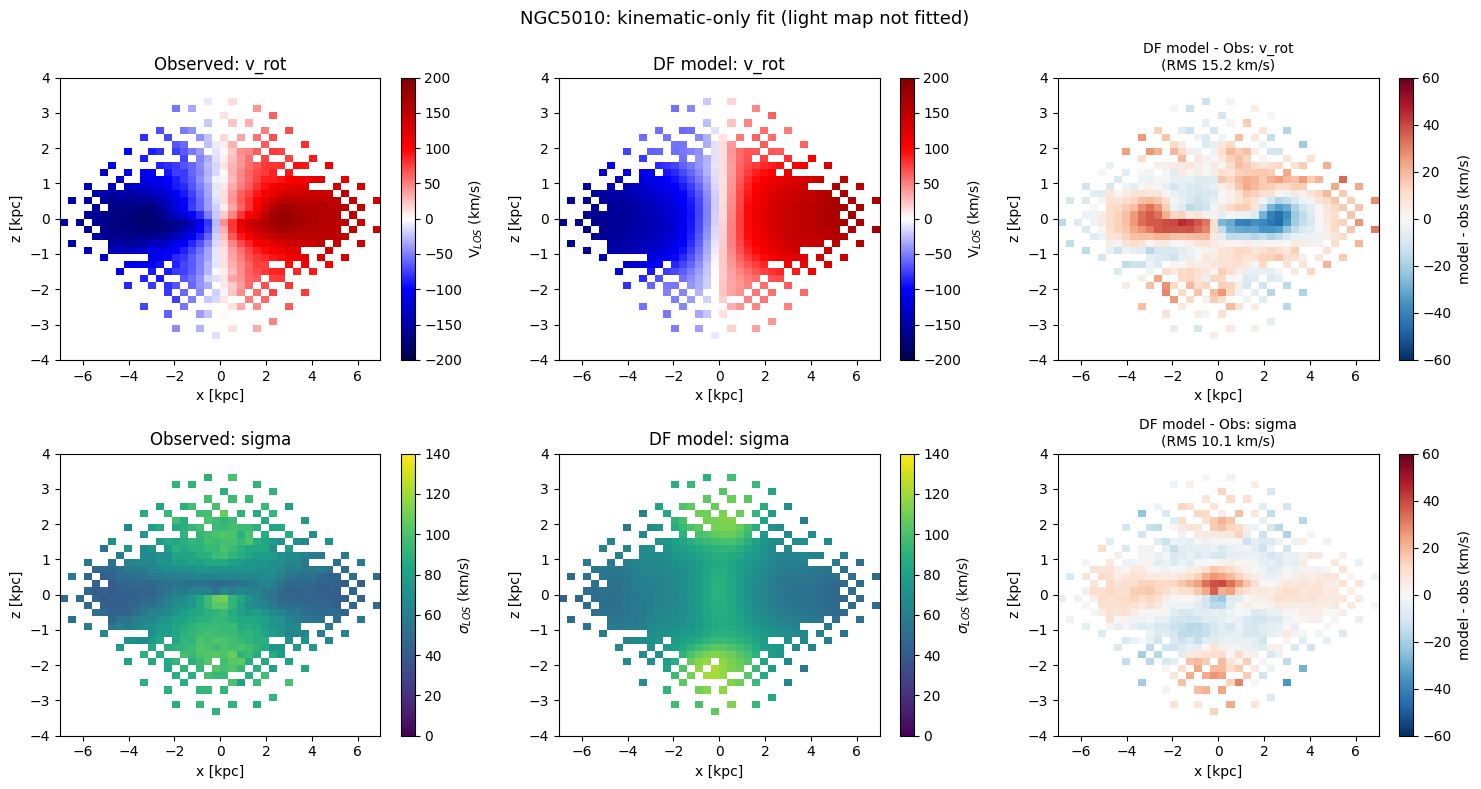

Residuals over the 558 cells with data:
  v_rot : RMS  15.18 km/s   median  +4.56   max|.|  46.32
  sigma : RMS  10.10 km/s   median  +0.79   max|.|  39.80


In [9]:
render_kw = dict(N_disk=N_PARTICLES_RENDER, N_bulge=N_PARTICLES_RENDER,
                 grid_size=GRID_SIZE, extent_x=EXTENT_X, extent_z=EXTENT_Z,
                 prng_seed=SEED, soft_bin_h=OBS_BANDWIDTH,
                 spheroid_corotation=SPHEROID_COROTATION, chunk=15_000)

maps_df = render_maps_batched(mapper, result['pot_params'],
                              result['disk_df_params'],
                              result['bulge_df_params'], **render_kw)

specs = [('v_rot', 'seismic', dict(vmin=-200, vmax=200), 'V$_{LOS}$ (km/s)'),
         ('sigma', 'viridis', dict(vmin=0, vmax=SIGMA_VMAX), '$\\sigma_{LOS}$ (km/s)')]

# 3 columns: Observed, DF model, Residual
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, (key, cmap, kw, label) in enumerate(specs):
    # Plot Observed and DF model
    for col, (t, arr) in enumerate([('Observed', obs_maps[key]),
                                    ('DF model', maps_df[key])]):
        im = axes[row, col].imshow(masked(arr), origin='lower', extent=EXTENT,
                                   cmap=cmap, aspect='auto', **kw)
        axes[row, col].set_title(f'{t}: {key}')
        fig.colorbar(im, ax=axes[row, col], label=label)

    # Plot Residual (DF model - Obs) in the 3rd column
    d = np.where(data_mask, np.array(maps_df[key]) - np.array(obs_maps[key]), np.nan)
    rms = float(np.sqrt(np.nanmean(d ** 2)))
    im = axes[row, 2].imshow(d, origin='lower', extent=EXTENT, cmap='RdBu_r',
                               vmin=-60, vmax=60, aspect='auto')
    axes[row, 2].set_title(f'DF model - Obs: {key}\n(RMS {rms:.1f} km/s)', fontsize=10)
    fig.colorbar(im, ax=axes[row, 2], label='model - obs (km/s)')

for ax in axes.ravel():
    ax.set_xlabel('x [kpc]'); ax.set_ylabel('z [kpc]')
fig.suptitle(f'{NAME}: kinematic-only fit (light map not fitted)', fontsize=13)
plt.tight_layout(); plt.show()

print(f"Residuals over the {int(data_mask.sum())} cells with data:")
for key in ('v_rot', 'sigma'):
    o = np.array(obs_maps[key])
    d = np.where(data_mask, np.array(maps_df[key]) - o, np.nan)
    print(f"  {key:6s}: RMS {np.sqrt(np.nanmean(d**2)):6.2f} km/s   "
          f"median {np.nanmedian(d):+6.2f}   max|.| {np.nanmax(np.abs(d)):6.2f}")


## 6. Fitted Parameters

No ground truth exists, so these are answers rather than scores. With a single optimization path there is no naive-vs-annealed cross-check, so the diagnostics left are: **~unmoved** — the value barely left the initial guess, i.e. the Tikhonov prior is holding it rather than the data; **frozen** — the loss gradient was numerically zero at the initial guess (Section 2); and bound proximity.

Bound proximity is measured in **log space**, the space the optimizer works in; a linear test is meaningless when a bound range spans orders of magnitude.


In [10]:
def flat_params(res):
    return {**res['pot_params'], **res['disk_df_params'], **res['bulge_df_params']}

pf = flat_params(result)
init_all = {**init_pot, **init_disk, **init_bulge}
bounds_all = {**param_bounds['pot'], **param_bounds['disk'], **param_bounds['bulge']}


def bound_flag(v, lo, hi, frac=0.02):
    if lo > 0 and v > 0 and hi > lo:
        f = (math.log(v) - math.log(lo)) / (math.log(hi) - math.log(lo))
    elif hi > lo:
        f = (v - lo) / (hi - lo)
    else:
        return ''
    if f <= frac:
        return 'AT LOWER BOUND'
    if f >= 1.0 - frac:
        return 'AT UPPER BOUND'
    return ''


print(f"{'parameter':16s} {'init':>11s} {'fitted':>11s} {'fit/init':>10s}  notes")
for k in init_all:
    v = float(pf[k])
    lo, hi = bounds_all[k]
    notes = []
    if k in FROZEN:
        notes.append('frozen (unconstrained)')
    bf = bound_flag(v, lo, hi)
    if bf:
        notes.append(bf)
    ratio = (v / init_all[k]) if init_all[k] != 0 else float('nan')
    if k not in FROZEN and abs(ratio - 1.0) < 0.05 and REG_WEIGHT > 0:
        notes.append('~unmoved: set by the prior, not the data')
    print(f"{k:16s} {init_all[k]:11.4g} {v:11.4g} {ratio:10.2f}  {', '.join(notes)}")


parameter               init      fitted   fit/init  notes
M_halo                 8e+11   1.295e+12       1.62  
a_halo                    15       31.13       2.08  
M_disk                 4e+10   4.908e+10       1.23  
a_disk                     2       2.169       1.08  
b_disk                   0.2      0.2917       1.46  
M_bulge                5e+09   7.188e+09       1.44  
a_bulge                  0.5       0.612       1.22  
R0                         4       4.566       1.14  
Rd                       1.5      0.9269       0.62  
Sigma0                  1000        1000       1.00  frozen (unconstrained)
RsigR                      5       5.607       1.12  
RsigZ                      5       3.005       0.60  
sigmaR0_R0                60       47.44       0.79  
sigmaz0_R0                40        49.5       1.24  
L0                         3       3.001       1.00  ~unmoved: set by the prior, not the data
Rinit_for_Rc               4           4       1.00  frozen (unconstr

## 7. Summary and Caveats

**Fitted:** the `V_LOS` and `sigma_LOS` maps of NGC 5010, `sigma` up-weighted, with a co-rotating spheroid (`spheroid_corotation=1.0`) and a well-centred field, at a **constant** smoothing bandwidth of 0.4 kpc.

**Not fitted:** the light map (`w_mass=0` — MUSE FLUX is light with a fiducial normalization) and self-consistency (`w_poisson=0` — a real galaxy cannot be pre-made self-consistent, so the term would impose a prior that cannot be validated against this galaxy first).

**Caveats, all of which apply to any number above:**

- **No ground truth.** A good map fit does not make the parameters right. Trust the `frozen` / `~unmoved` flags over the fitted values.
- **A single optimization path.** Without the annealed run there is no path-agreement check, so a parameter that this run pins down confidently may still be poorly constrained by the data.
- **Light is not mass.** `M_disk`/`M_bulge` absorb the constant-M/L assumption; only the velocities carry an absolute physical scale.
- **Self-consistency is not enforced**, so the fitted model is not guaranteed to be a dynamically valid galaxy.
- **Axisymmetric model.** NGC 5010's coverage is symmetric (unlike NGC 3630's), which is a better match to the model's assumptions — but real galaxies still have non-axisymmetric structure the model cannot represent.
- **Reduced tracer count:** 20,000 tracers and 600 steps here for runtime, against 35,000 / 700 in `fit_geckos.py`, so the Monte-Carlo noise floor is slightly higher than necessary.
- **Distance and M\*** are catalogue values; an error there propagates directly into the inferred masses and scale lengths.
